---
## 1. Import Library & Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print('✅ Library berhasil diimpor.')

✅ Library berhasil diimpor.


## 2. Fungsi Simulasi Utama

In [2]:
def run_simulation(N, min_dur=1, max_dur=3, seed=None):
    """
    Simulasi Pembagian Lembar Jawaban Ujian (Discrete Event Simulation).
    
    Parameters:
        N        : Jumlah mahasiswa
        min_dur  : Batas bawah durasi pelayanan (menit)
        max_dur  : Batas atas durasi pelayanan (menit)
        seed     : Random seed untuk reproducibility
    
    Returns:
        DataFrame hasil simulasi, total waktu, rata-rata tunggu, utilisasi
    """
    rng = np.random.default_rng(seed)
    
    records = []
    current_time = 0.0  # Waktu server saat ini (kapan server bebas)
    
    for i in range(1, N + 1):
        # Mahasiswa ke-i mulai dilayani saat server bebas
        start_service = current_time
        
        # Durasi pelayanan acak dari Uniform(min_dur, max_dur)
        service_time = rng.uniform(min_dur, max_dur)
        
        # Waktu selesai
        end_service = start_service + service_time
        
        # Waktu tunggu (akumulasi dari mahasiswa sebelumnya)
        wait_time = start_service  # semua tiba di t=0

        records.append({
            'Mahasiswa': i,
            'Mulai Dilayani (menit)': round(start_service, 2),
            'Durasi Pelayanan (menit)': round(service_time, 2),
            'Selesai Dilayani (menit)': round(end_service, 2),
            'Waktu Tunggu (menit)': round(wait_time, 2)
        })
        
        current_time = end_service
    
    df = pd.DataFrame(records)
    total_time = current_time
    avg_wait = df['Waktu Tunggu (menit)'].mean()
    utilisasi = (df['Durasi Pelayanan (menit)'].sum() / total_time) * 100
    
    return df, total_time, avg_wait, utilisasi

print('✅ Fungsi simulasi siap.')

✅ Fungsi simulasi siap.


---
## 3. Jalankan Simulasi Dasar

In [3]:
N = 30
df, total_time, avg_wait, utilisasi = run_simulation(N, seed=42)

print(f"{'='*50}")
print(f"  HASIL SIMULASI — {N} Mahasiswa")
print(f"{'='*50}")
print(f"  Total Waktu Pembagian  : {total_time:.2f} menit")
print(f"  Rata-rata Waktu Tunggu : {avg_wait:.2f} menit")
print(f"  Utilisasi Meja Pengajar: {utilisasi:.1f}%")
print(f"{'='*50}")
print()
print("Event Tracing (5 mahasiswa pertama):")
print(df.head())
print()
print("Event Tracing (5 mahasiswa terakhir):")
print(df.tail())

  HASIL SIMULASI — 30 Mahasiswa
  Total Waktu Pembagian  : 63.55 menit
  Rata-rata Waktu Tunggu : 31.67 menit
  Utilisasi Meja Pengajar: 100.0%

Event Tracing (5 mahasiswa pertama):
   Mahasiswa  Mulai Dilayani (menit)  Durasi Pelayanan (menit)  \
0          1                    0.00                      2.55   
1          2                    2.55                      1.88   
2          3                    4.43                      2.72   
3          4                    7.14                      2.39   
4          5                    9.54                      1.19   

   Selesai Dilayani (menit)  Waktu Tunggu (menit)  
0                      2.55                  0.00  
1                      4.43                  2.55  
2                      7.14                  4.43  
3                      9.54                  7.14  
4                     10.73                  9.54  

Event Tracing (5 mahasiswa terakhir):
    Mahasiswa  Mulai Dilayani (menit)  Durasi Pelayanan (menit)  \
25 

---
## 4. Visualisasi Hasil Simulasi

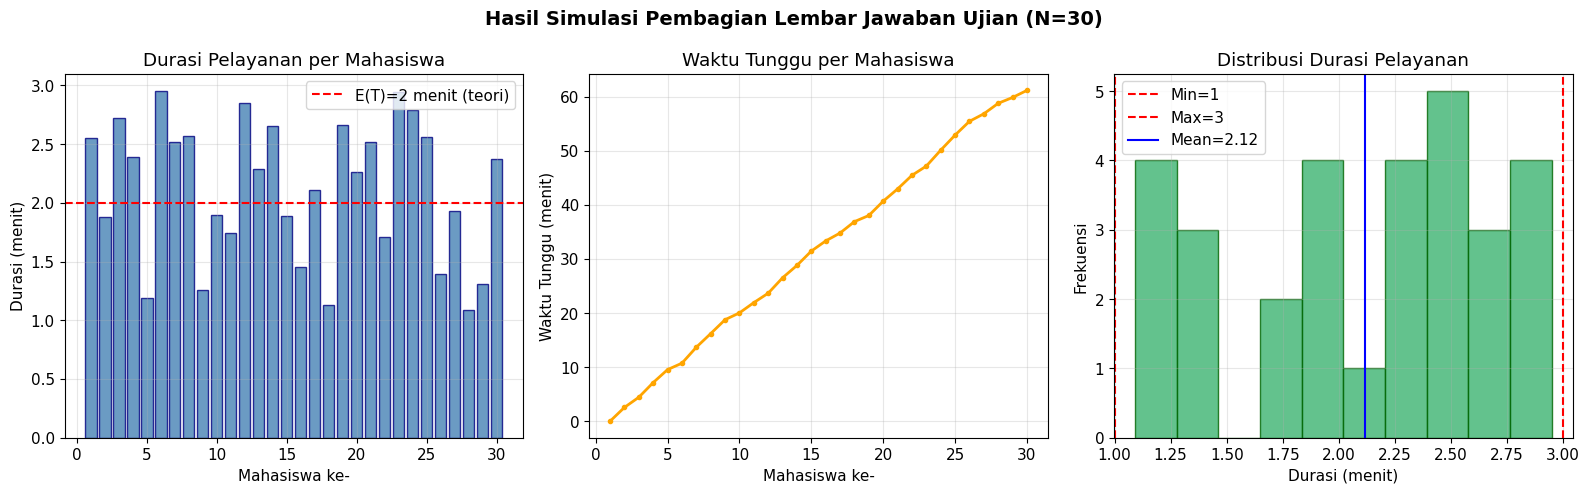

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(f'Hasil Simulasi Pembagian Lembar Jawaban Ujian (N={N})',
             fontsize=14, fontweight='bold')

# Plot 1: Durasi pelayanan setiap mahasiswa
axes[0].bar(df['Mahasiswa'], df['Durasi Pelayanan (menit)'],
            color='steelblue', alpha=0.8, edgecolor='navy')
axes[0].axhline(y=2.0, color='red', linestyle='--', label='E(T)=2 menit (teori)')
axes[0].set_title('Durasi Pelayanan per Mahasiswa')
axes[0].set_xlabel('Mahasiswa ke-')
axes[0].set_ylabel('Durasi (menit)')
axes[0].legend()

# Plot 2: Waktu tunggu kumulatif
axes[1].plot(df['Mahasiswa'], df['Waktu Tunggu (menit)'],
             color='orange', marker='o', markersize=3, linewidth=2)
axes[1].set_title('Waktu Tunggu per Mahasiswa')
axes[1].set_xlabel('Mahasiswa ke-')
axes[1].set_ylabel('Waktu Tunggu (menit)')

# Plot 3: Histogram distribusi durasi pelayanan
axes[2].hist(df['Durasi Pelayanan (menit)'], bins=10,
             color='mediumseagreen', edgecolor='darkgreen', alpha=0.8)
axes[2].axvline(x=1, color='red', linestyle='--', label='Min=1')
axes[2].axvline(x=3, color='red', linestyle='--', label='Max=3')
axes[2].axvline(x=df['Durasi Pelayanan (menit)'].mean(), color='blue',
                linestyle='-',
                label=f"Mean={df['Durasi Pelayanan (menit)'].mean():.2f}")
axes[2].set_title('Distribusi Durasi Pelayanan')
axes[2].set_xlabel('Durasi (menit)')
axes[2].set_ylabel('Frekuensi')
axes[2].legend()

plt.tight_layout()
plt.show()

## 5. Verifikasi Model

In [5]:
print("=== VERIFIKASI: Logical Flow Check ===")
overlap = False
for i in range(len(df) - 1):
    end_i    = df.iloc[i]['Selesai Dilayani (menit)']
    start_nx = df.iloc[i+1]['Mulai Dilayani (menit)']
    if start_nx < end_i:
        print(f"  ⚠️  Tumpang tindih di mahasiswa {i+1} dan {i+2}!")
        overlap = True

if not overlap:
    print("  ✅ Tidak ada tumpang tindih waktu pelayanan.")
    print("  ✅ Setiap mahasiswa dilayani satu per satu secara berurutan.")
print()

=== VERIFIKASI: Logical Flow Check ===
  ✅ Tidak ada tumpang tindih waktu pelayanan.
  ✅ Setiap mahasiswa dilayani satu per satu secara berurutan.



### 5b. 5 Mahasiswa Pertama

In [6]:
print("=== VERIFIKASI: Event Tracing (5 Mahasiswa Pertama) ===")
for _, row in df.head(5).iterrows():
    print(f"  Mahasiswa {int(row['Mahasiswa']):2d}: "
          f"Mulai={row['Mulai Dilayani (menit)']:5.2f} mnt | "
          f"Durasi={row['Durasi Pelayanan (menit)']:4.2f} mnt | "
          f"Selesai={row['Selesai Dilayani (menit)']:5.2f} mnt")
print()

=== VERIFIKASI: Event Tracing (5 Mahasiswa Pertama) ===
  Mahasiswa  1: Mulai= 0.00 mnt | Durasi=2.55 mnt | Selesai= 2.55 mnt
  Mahasiswa  2: Mulai= 2.55 mnt | Durasi=1.88 mnt | Selesai= 4.43 mnt
  Mahasiswa  3: Mulai= 4.43 mnt | Durasi=2.72 mnt | Selesai= 7.14 mnt
  Mahasiswa  4: Mulai= 7.14 mnt | Durasi=2.39 mnt | Selesai= 9.54 mnt
  Mahasiswa  5: Mulai= 9.54 mnt | Durasi=1.19 mnt | Selesai=10.73 mnt



### 5c. Uji Kondisi Ekstrem

In [7]:
print("=== VERIFIKASI: Uji Kondisi Ekstrem ===")
print()

# Skenario 1: N = 1
df1, t1, _, _ = run_simulation(1, seed=42)
match1 = abs(t1 - df1.iloc[0]['Durasi Pelayanan (menit)']) < 0.01
print(f"  N=1: Total={t1:.2f} mnt | Durasi mhs-1={df1.iloc[0]['Durasi Pelayanan (menit)']:.2f} mnt"
      f" → {'✅ Sesuai' if match1 else '❌ Tidak Sesuai'}")

# Skenario 2: Durasi tetap = 1 menit
df2, t2, _, _ = run_simulation(30, min_dur=1, max_dur=1, seed=42)
expected2 = 30 * 1
print(f"  Durasi tetap 1 mnt: Total={t2:.2f} mnt | Ekspektasi={expected2} mnt"
      f" → {'✅ Sesuai' if abs(t2 - expected2) < 0.01 else '❌ Tidak Sesuai'}")

# Skenario 3: Durasi tetap = 3 menit
df3, t3, _, _ = run_simulation(30, min_dur=3, max_dur=3, seed=42)
expected3 = 30 * 3
print(f"  Durasi tetap 3 mnt: Total={t3:.2f} mnt | Ekspektasi={expected3} mnt"
      f" → {'✅ Sesuai' if abs(t3 - expected3) < 0.01 else '❌ Tidak Sesuai'}")
print()

=== VERIFIKASI: Uji Kondisi Ekstrem ===

  N=1: Total=2.55 mnt | Durasi mhs-1=2.55 mnt → ✅ Sesuai
  Durasi tetap 1 mnt: Total=30.00 mnt | Ekspektasi=30 mnt → ✅ Sesuai
  Durasi tetap 3 mnt: Total=90.00 mnt | Ekspektasi=90 mnt → ✅ Sesuai



### 5d. Pemeriksaan Distribusi Waktu Pelayanan

In [8]:
print("=== VERIFIKASI: Distribusi Waktu Pelayanan ===")
durations = df['Durasi Pelayanan (menit)']
print(f"  Min  : {durations.min():.2f} mnt | batas bawah = 1 mnt "
      f"{'✅' if durations.min() >= 1 else '❌'}")
print(f"  Max  : {durations.max():.2f} mnt | batas atas  = 3 mnt "
      f"{'✅' if durations.max() <= 3 else '❌'}")
print(f"  Mean : {durations.mean():.2f} mnt | teori = 2.00 mnt")
print(f"  Std  : {durations.std():.4f}")
print()

=== VERIFIKASI: Distribusi Waktu Pelayanan ===
  Min  : 1.09 mnt | batas bawah = 1 mnt ✅
  Max  : 2.95 mnt | batas atas  = 3 mnt ✅
  Mean : 2.12 mnt | teori = 2.00 mnt
  Std  : 0.5917



### 5e. Reproducibility Check

In [9]:
print("=== VERIFIKASI: Reproducibility Check ===")
_, t_r1, _, _ = run_simulation(30, seed=99)
_, t_r2, _, _ = run_simulation(30, seed=99)
_, t_r3, _, _ = run_simulation(30, seed=99)
print(f"  Run 1 (seed=99): {t_r1:.4f} mnt")
print(f"  Run 2 (seed=99): {t_r2:.4f} mnt")
print(f"  Run 3 (seed=99): {t_r3:.4f} mnt")
all_same = (t_r1 == t_r2 == t_r3)
print(f"  {'✅ Identik — Reproducibility terpenuhi.' if all_same else '❌ Tidak identik!'}")
print()
print("=== KESIMPULAN VERIFIKASI ===")
print("  ✅ Logika alur sesuai asumsi sistem")
print("  ✅ Event tracing berjalan kronologis")
print("  ✅ Uji kondisi ekstrem memberikan hasil sesuai")
print("  ✅ Distribusi waktu pelayanan dalam rentang Uniform(1,3)")
print("  ✅ Model reproducible dengan seed yang sama")
print("  → Model telah terverifikasi dengan benar.")

=== VERIFIKASI: Reproducibility Check ===
  Run 1 (seed=99): 62.0745 mnt
  Run 2 (seed=99): 62.0745 mnt
  Run 3 (seed=99): 62.0745 mnt
  ✅ Identik — Reproducibility terpenuhi.

=== KESIMPULAN VERIFIKASI ===
  ✅ Logika alur sesuai asumsi sistem
  ✅ Event tracing berjalan kronologis
  ✅ Uji kondisi ekstrem memberikan hasil sesuai
  ✅ Distribusi waktu pelayanan dalam rentang Uniform(1,3)
  ✅ Model reproducible dengan seed yang sama
  → Model telah terverifikasi dengan benar.



## 6. Validasi Model (Section 1.3)



In [10]:
print("=== VALIDASI: Face Validation ===")
print(f"  Total waktu untuk N=30 : {total_time:.2f} menit")
in_range = 45 <= total_time <= 90
print(f"  Rentang yang diharapkan : 45–90 menit")
print(f"  {'✅ Masuk rentang realistis.' if in_range else '❌ Di luar rentang.'}")
print(f"  Utilisasi meja pengajar : {utilisasi:.1f}% (diharapkan mendekati 100%)")
print()

=== VALIDASI: Face Validation ===
  Total waktu untuk N=30 : 63.55 menit
  Rentang yang diharapkan : 45–90 menit
  ✅ Masuk rentang realistis.
  Utilisasi meja pengajar : 100.0% (diharapkan mendekati 100%)



### 6b. Perbandingan dengan Perhitungan Teoritis

=== VALIDASI: Perbandingan dengan Nilai Teoritis ===
  Nilai Teoritis   : E(T) = (1+3)/2 = 2 mnt → Total = 30×2 = 60 mnt
  Rata-rata Simulasi (500 replikasi): 60.26 mnt
  Std Dev Simulasi : 3.17 mnt
  Selisih relatif  : 0.43%
  ✅ Mendekati nilai teoritis.



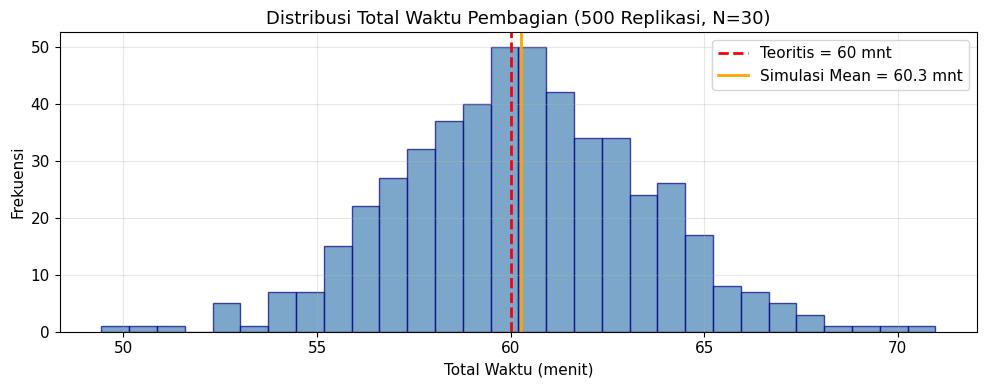

In [11]:
# Jalankan 500 replikasi untuk mendapatkan rata-rata
N_rep = 500
totals = []
for s in range(N_rep):
    _, t, _, _ = run_simulation(30, seed=s)
    totals.append(t)

theoretical  = 30 * 2   # N × E(T) = 30 × 2 menit
sim_mean     = np.mean(totals)
sim_std      = np.std(totals)
error_pct    = abs(sim_mean - theoretical) / theoretical * 100

print("=== VALIDASI: Perbandingan dengan Nilai Teoritis ===")
print(f"  Nilai Teoritis   : E(T) = (1+3)/2 = 2 mnt → Total = 30×2 = {theoretical} mnt")
print(f"  Rata-rata Simulasi ({N_rep} replikasi): {sim_mean:.2f} mnt")
print(f"  Std Dev Simulasi : {sim_std:.2f} mnt")
print(f"  Selisih relatif  : {error_pct:.2f}%")
print(f"  {'✅ Mendekati nilai teoritis.' if error_pct < 5 else '⚠️ Cukup jauh dari teori.'}")
print()

# Visualisasi distribusi total waktu (500 replikasi)
plt.figure(figsize=(10, 4))
plt.hist(totals, bins=30, color='steelblue', edgecolor='navy', alpha=0.7)
plt.axvline(x=theoretical, color='red',    linestyle='--', linewidth=2,
            label=f'Teoritis = {theoretical} mnt')
plt.axvline(x=sim_mean,    color='orange', linestyle='-',  linewidth=2,
            label=f'Simulasi Mean = {sim_mean:.1f} mnt')
plt.title(f'Distribusi Total Waktu Pembagian ({N_rep} Replikasi, N=30)', fontsize=13)
plt.xlabel('Total Waktu (menit)')
plt.ylabel('Frekuensi')
plt.legend()
plt.tight_layout()
plt.show()

### 6c. Behavior Validation 

=== VALIDASI: Behavior Validation ===
  Uji: N meningkat → Total waktu meningkat
    N=10 → Rata-rata total waktu = 20.1 mnt
    N=20 → Rata-rata total waktu = 40.0 mnt
    N=30 → Rata-rata total waktu = 59.9 mnt
    N=40 → Rata-rata total waktu = 80.0 mnt
    N=50 → Rata-rata total waktu = 100.0 mnt
  ✅ Total waktu meningkat seiring N.



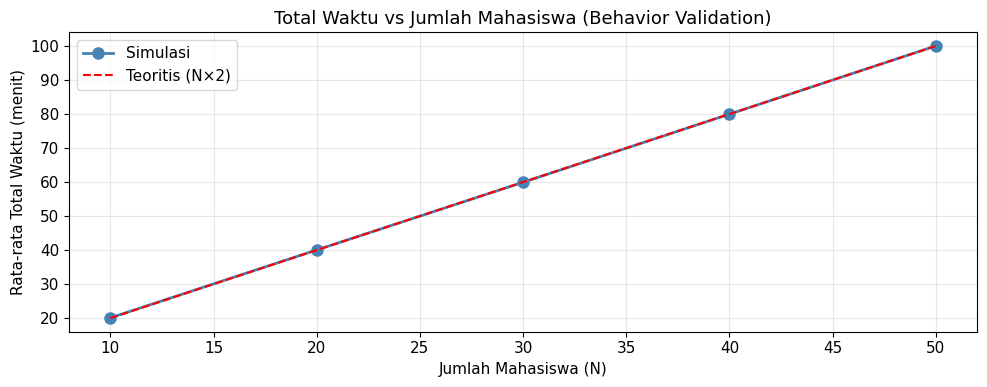

In [12]:
print("=== VALIDASI: Behavior Validation ===")

N_values    = [10, 20, 30, 40, 50]
times_by_N  = []

for n in N_values:
    means = [run_simulation(n, seed=s)[1] for s in range(100)]
    times_by_N.append(np.mean(means))

print("  Uji: N meningkat → Total waktu meningkat")
for n, t in zip(N_values, times_by_N):
    print(f"    N={n:2d} → Rata-rata total waktu = {t:.1f} mnt")

monotone = all(times_by_N[i] < times_by_N[i+1] for i in range(len(times_by_N)-1))
print(f"  {'✅ Total waktu meningkat seiring N.' if monotone else '❌ Tidak monoton!'}")
print()

# Visualisasi
plt.figure(figsize=(10, 4))
plt.plot(N_values, times_by_N,
         'o-', color='steelblue', linewidth=2, markersize=8, label='Simulasi')
plt.plot(N_values, [n * 2 for n in N_values],
         'r--', label='Teoritis (N×2)')
plt.title('Total Waktu vs Jumlah Mahasiswa (Behavior Validation)', fontsize=13)
plt.xlabel('Jumlah Mahasiswa (N)')
plt.ylabel('Rata-rata Total Waktu (menit)')
plt.legend()
plt.tight_layout()
plt.show()

### 6d. Sensitivity Analysis

=== VALIDASI: Sensitivity Analysis ===
                  Skenario  Rata-rata Total Waktu  Std Dev  E(T) Teoritis
   Uniform(1,3) [baseline]                  60.21     2.89            2.0
       Uniform(2,4) [naik]                  90.21     2.89            3.0
Uniform(1,5) [lebih lebar]                  90.42     5.78            3.0

  ✅ Total waktu meningkat saat distribusi durasi bergeser lebih besar.
  ✅ Model sensitif terhadap parameter utama distribusi pelayanan.


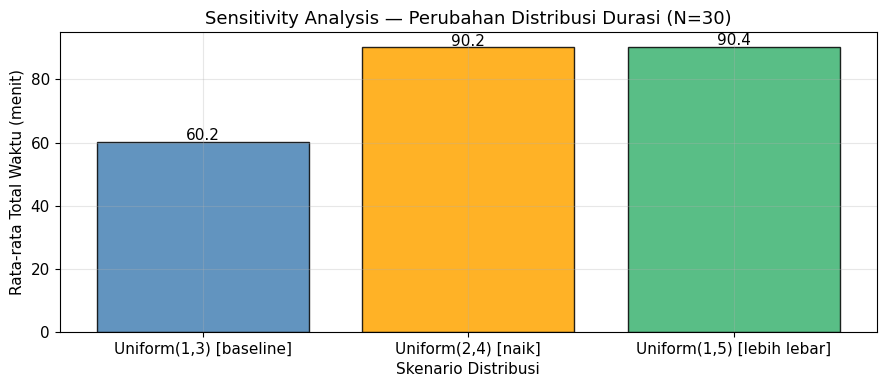

In [13]:
print("=== VALIDASI: Sensitivity Analysis ===")

scenarios = [
    {'label': 'Uniform(1,3) [baseline]', 'min': 1, 'max': 3},
    {'label': 'Uniform(2,4) [naik]',     'min': 2, 'max': 4},
    {'label': 'Uniform(1,5) [lebih lebar]', 'min': 1, 'max': 5},
]

sc_data = []
for sc in scenarios:
    vals = [run_simulation(30, sc['min'], sc['max'], seed=s)[1] for s in range(200)]
    sc_data.append({
        'Skenario'               : sc['label'],
        'Rata-rata Total Waktu'  : round(np.mean(vals), 2),
        'Std Dev'                : round(np.std(vals),  2),
        'E(T) Teoritis'          : (sc['min'] + sc['max']) / 2,
    })

df_sc = pd.DataFrame(sc_data)
print(df_sc.to_string(index=False))
print()
print("  ✅ Total waktu meningkat saat distribusi durasi bergeser lebih besar.")
print("  ✅ Model sensitif terhadap parameter utama distribusi pelayanan.")

# Visualisasi
fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(df_sc['Skenario'], df_sc['Rata-rata Total Waktu'],
              color=['steelblue', 'orange', 'mediumseagreen'],
              edgecolor='black', alpha=0.85)
for bar, val in zip(bars, df_sc['Rata-rata Total Waktu']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f'{val:.1f}', ha='center', fontsize=11)
ax.set_title('Sensitivity Analysis — Perubahan Distribusi Durasi (N=30)', fontsize=13)
ax.set_ylabel('Rata-rata Total Waktu (menit)')
ax.set_xlabel('Skenario Distribusi')
plt.tight_layout()
plt.show()

---
## 7. Kesimpulan Akhir

In [14]:
print("="*60)
print("  KESIMPULAN AKHIR")
print("="*60)
print()
print("VERIFIKASI:")
print("  ✅ Model diimplementasikan sesuai logika sistem FIFO single-server")
print("  ✅ Tidak ada tumpang tindih waktu pelayanan")
print("  ✅ Hasil uji kondisi ekstrem sesuai ekspektasi")
print("  ✅ Distribusi pelayanan berada dalam Uniform(1,3)")
print("  ✅ Model reproducible dengan random seed yang sama")
print()
print("VALIDASI:")
print("  ✅ Hasil simulasi masuk dalam rentang realistis (45–90 mnt untuk N=30)")
print(f"  ✅ Rata-rata simulasi ({sim_mean:.1f} mnt) mendekati nilai teoritis ({theoretical} mnt)")
print("  ✅ Total waktu meningkat seiring bertambahnya N")
print("  ✅ Model sensitif terhadap perubahan parameter distribusi")
print()
print("KESIMPULAN:")
print("  Model simulasi Pembagian Lembar Jawaban Ujian telah")
print("  terverifikasi dan tervalidasi. Model layak digunakan")
print("  sebagai alat bantu analisis durasi proses pembagian.")
print("="*60)

  KESIMPULAN AKHIR

VERIFIKASI:
  ✅ Model diimplementasikan sesuai logika sistem FIFO single-server
  ✅ Tidak ada tumpang tindih waktu pelayanan
  ✅ Hasil uji kondisi ekstrem sesuai ekspektasi
  ✅ Distribusi pelayanan berada dalam Uniform(1,3)
  ✅ Model reproducible dengan random seed yang sama

VALIDASI:
  ✅ Hasil simulasi masuk dalam rentang realistis (45–90 mnt untuk N=30)
  ✅ Rata-rata simulasi (60.3 mnt) mendekati nilai teoritis (60 mnt)
  ✅ Total waktu meningkat seiring bertambahnya N
  ✅ Model sensitif terhadap perubahan parameter distribusi

KESIMPULAN:
  Model simulasi Pembagian Lembar Jawaban Ujian telah
  terverifikasi dan tervalidasi. Model layak digunakan
  sebagai alat bantu analisis durasi proses pembagian.
